# CS610 Assignment 2 | Question 3: Multi-class classification

## Part 0: Setup and Imports

Install required libraries (run once on Colab).

In [1]:
!pip install torch optuna openpyxl scikit-learn matplotlib seaborn -q

Import all libraries used throughout this notebook.

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (confusion_matrix, f1_score, classification_report,
                             ConfusionMatrixDisplay, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

DEVICE = torch.device('cpu')
print(f"Using device: {DEVICE}")


Using device: cpu


Create output folder structure for saving checkpoints, results, and plots.

In [3]:
BASE_DIR = '/content/drive/MyDrive/SMUGroup/AML_Group_Project/Assignment'
os.makedirs(f'{BASE_DIR}/outputs/checkpoints', exist_ok=True)
os.makedirs(f'{BASE_DIR}/outputs/results', exist_ok=True)
print("Folder structure created:")
for root, dirs, files in os.walk(f'{BASE_DIR}/outputs'):
    level = root.replace(f'{BASE_DIR}/outputs', '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")


Folder structure created:
outputs/
  checkpoints/
  results/


Mount Drive, Load Dataset

In [4]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/SMUGroup/AML_Group_Project/Assignment

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SMUGroup/AML_Group_Project/Assignment


In [6]:
DATA_PATH = 'students_grades.xlsx'

df = pd.read_excel(DATA_PATH)

---
## Part 1: Exploratory Data Analysis (EDA)

Load the dataset and inspect its basic properties.

In [7]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")
df.head()


Shape: 649 rows, 22 columns

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'romantic', 'famrel', 'health', 'absences', 'target']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,famsup,paid,activities,nursery,higher,romantic,famrel,health,absences,target
0,GP,F,18.0,U,GT3,A,4.0,4.0,17.7,209.0,...,no,no,no,yes,yes,no,good,fair,4.0,D
1,NaN,F,17.0,U,GT3,T,1.0,1.0,10.7,143.0,...,yes,no,no,no,yes,no,very good,fair,2.0,C
2,GP,F,15.0,U,LE3,T,1.0,1.0,8.6,133.0,...,no,no,no,yes,yes,no,good,fair,6.0,B
3,GP,F,15.0,U,GT3,NaN,4.0,2.0,7.4,546.0,...,yes,no,yes,yes,yes,yes,fair,very good,0.0,A
4,GP,F,16.0,U,GT3,T,NaN,3.0,7.3,204.0,...,yes,no,no,yes,yes,no,good,very good,0.0,B


Check data types and basic statistics for numerical columns.

In [8]:
print("Data types:")
print(df.dtypes)
print("\nNumerical summary:")
df.describe()


Data types:
school         object
sex            object
age           float64
address        object
famsize        object
Pstatus        object
Medu          float64
Fedu          float64
traveltime    float64
studytime     float64
failures      float64
schoolsup      object
famsup         object
paid           object
activities     object
nursery        object
higher         object
romantic       object
famrel         object
health         object
absences      float64
target         object
dtype: object

Numerical summary:


,age,Medu,Fedu,traveltime,studytime,failures,absences
count,633.000000,633.000000,639.000000,629.000000,634.000000,637.000000,635.000000
mean,16.747235,2.508689,2.306729,18.503021,240.735016,0.224490,3.694488
std,1.214077,1.136424,1.099930,16.276975,216.229551,0.597292,4.671332
min,15.000000,0.000000,0.000000,3.000000,5.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,8.700000,96.000000,0.000000,0.000000
50%,17.000000,2.000000,2.000000,13.500000,191.000000,0.000000,2.000000
75%,18.000000,4.000000,3.000000,23.800000,283.000000,0.000000,6.000000
max,22.000000,4.000000,4.000000,119.600000,1199.000000,3.000000,32.000000


Check the target variable distribution.

Target distribution:
target
A    162
B    162
C    162
D    163
Name: count, dtype: int64



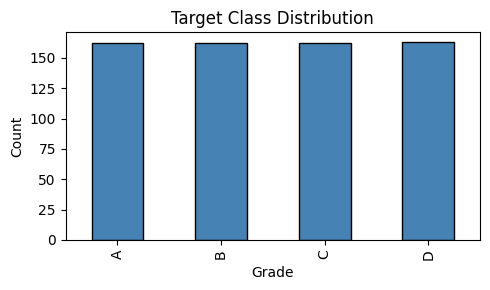

In [9]:
print("Target distribution:")
print(df['target'].value_counts().sort_index())
print()

fig, ax = plt.subplots(figsize=(5, 3))
df['target'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Target Class Distribution')
ax.set_xlabel('Grade')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


### Missing Value Analysis

We check missing values at two levels:
1. Per-feature missing count and percentage.
2. Total rows with at least one missing value as a percentage of all rows.

If the row-level missing percentage exceeds 5%, dropping rows is not viable and we should impute instead.

In [10]:
# Per-feature missing count and percentage
missing_info = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print("Missing values per feature:")
print(missing_info)

# Row-level: how many rows have at least one missing value
total_rows = len(df)
rows_with_missing = df.isnull().any(axis=1).sum()
pct_rows_missing = rows_with_missing / total_rows * 100

print(f"\nTotal rows: {total_rows}")
print(f"Rows with at least one missing value: {rows_with_missing} ({pct_rows_missing:.2f}%)")
print(f"Rows remaining if dropped: {total_rows - rows_with_missing}")

if pct_rows_missing > 5:
    print(f"\n>> {pct_rows_missing:.2f}% far exceeds the 5% threshold.")
    print(">> Dropping these rows would lose nearly half the dataset. We will impute instead.")
else:
    print(f"\n>> {pct_rows_missing:.2f}% is below 5%. Dropping rows is acceptable.")


Missing values per feature:
            Missing Count  Missing %
school                 13       2.00
sex                    10       1.54
age                    16       2.47
address                12       1.85
famsize                14       2.16
Pstatus                18       2.77
Medu                   16       2.47
Fedu                   10       1.54
traveltime             20       3.08
studytime              15       2.31
failures               12       1.85
schoolsup              13       2.00
famsup                 14       2.16
paid                   13       2.00
activities              9       1.39
nursery                 6       0.92
higher                 13       2.00
romantic               12       1.85
famrel                  9       1.39
health                 12       1.85
absences               14       2.16
target                  0       0.00

Total rows: 649
Rows with at least one missing value: 271 (41.76%)
Rows remaining if dropped: 378

>> 41.76% far exceeds

---
## Part 2: Data Preprocessing

### 2.1 Handle Missing Values via Imputation

Since 41.76% of rows contain at least one missing value (far exceeding the 5% threshold), we impute rather than drop:
- Numerical columns: fill with median (robust to outliers).
- Categorical columns: fill with mode (most frequent value). Even imputing categorical columns with mode value may introduce bias, but in this case,  each individual column has very low missing rates (1 to 3%), so the distortion per column is small even if it adds up across columns.

In [11]:
numerical_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'absences']
categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
                    'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
                    'higher', 'romantic', 'famrel', 'health']

# Fill numerical with median
for col in numerical_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  {col}: filled {df[col].isnull().sum()} remaining NaNs with median={median_val}")

# Fill categorical with mode
for col in categorical_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"  {col}: filled with mode='{mode_val}'")

print(f"\nTotal missing values after imputation: {df.isnull().sum().sum()}")


  age: filled 0 remaining NaNs with median=17.0
  Medu: filled 0 remaining NaNs with median=2.0
  Fedu: filled 0 remaining NaNs with median=2.0
  traveltime: filled 0 remaining NaNs with median=13.5
  studytime: filled 0 remaining NaNs with median=191.0
  failures: filled 0 remaining NaNs with median=0.0
  absences: filled 0 remaining NaNs with median=2.0
  school: filled with mode='GP'
  sex: filled with mode='F'
  address: filled with mode='U'
  famsize: filled with mode='GT3'
  Pstatus: filled with mode='T'
  schoolsup: filled with mode='no'
  famsup: filled with mode='yes'
  paid: filled with mode='no'
  activities: filled with mode='no'
  nursery: filled with mode='yes'
  higher: filled with mode='yes'
  romantic: filled with mode='no'
  famrel: filled with mode='good'
  health: filled with mode='very good'

Total missing values after imputation: 0


### 2.2 Encode Features

- Binary categorical columns: label encode to 0/1.
- Ordinal columns (`famrel`, `health`): map to numeric scale (1=very bad to 5=very good).
- Target: A=0, B=1, C=2, D=3.

In [12]:
# Binary categorical columns
binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
               'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
               'higher', 'romantic']

le_dict = {}
for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Ordinal columns
ordinal_map = {'very bad': 1, 'bad': 2, 'fair': 3, 'good': 4, 'very good': 5}
df['famrel'] = df['famrel'].map(ordinal_map)
df['health'] = df['health'].map(ordinal_map)
print(f"\n  famrel, health: very bad=1, bad=2, fair=3, good=4, very good=5")

# Target
target_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
df['target'] = df['target'].map(target_map)
print(f"  target: {target_map}")

print("\nEncoded data sample:")
df.head()


  school: {'GP': np.int64(0), 'MS': np.int64(1)}
  sex: {'F': np.int64(0), 'M': np.int64(1)}
  address: {'R': np.int64(0), 'U': np.int64(1)}
  famsize: {'GT3': np.int64(0), 'LE3': np.int64(1)}
  Pstatus: {'A': np.int64(0), 'T': np.int64(1)}
  schoolsup: {'no': np.int64(0), 'yes': np.int64(1)}
  famsup: {'no': np.int64(0), 'yes': np.int64(1)}
  paid: {'no': np.int64(0), 'yes': np.int64(1)}
  activities: {'no': np.int64(0), 'yes': np.int64(1)}
  nursery: {'no': np.int64(0), 'yes': np.int64(1)}
  higher: {'no': np.int64(0), 'yes': np.int64(1)}
  romantic: {'no': np.int64(0), 'yes': np.int64(1)}

  famrel, health: very bad=1, bad=2, fair=3, good=4, very good=5
  target: {'A': 0, 'B': 1, 'C': 2, 'D': 3}

Encoded data sample:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,famsup,paid,activities,nursery,higher,romantic,famrel,health,absences,target
0,0,0,18.0,1,0,0,4.0,4.0,17.7,209.0,...,0,0,0,1,1,0,4,3,4.0,3
1,0,0,17.0,1,0,1,1.0,1.0,10.7,143.0,...,1,0,0,0,1,0,5,3,2.0,2
2,0,0,15.0,1,1,1,1.0,1.0,8.6,133.0,...,0,0,0,1,1,0,4,3,6.0,1
3,0,0,15.0,1,0,1,4.0,2.0,7.4,546.0,...,1,0,1,1,1,1,3,5,0.0,0
4,0,0,16.0,1,0,1,2.0,3.0,7.3,204.0,...,1,0,0,1,1,0,4,5,0.0,1


### 2.3 Stratified 60:20:20 Train / Validation / Test Split

We use stratified sampling to maintain class balance across all three splits.

In [13]:
X = df.drop('target', axis=1).values
y = df['target'].values

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=SEED, stratify=y
)

# Second split: split 40% into 20%/20%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")
print(f"\nTrain target distribution: {np.bincount(y_train)}")
print(f"Val target distribution:   {np.bincount(y_val)}")
print(f"Test target distribution:  {np.bincount(y_test)}")


Train: 389 samples
Val:   130 samples
Test:  130 samples

Train target distribution: [97 97 97 98]
Val target distribution:   [32 33 32 33]
Test target distribution:  [33 32 33 32]


### 2.4 Feature Scaling with StandardScaler

StandardScaler transforms each feature to have mean=0 and std=1: `z = (x - mean) / std`.

Neural networks learn through gradient descent. If features have very different scales (e.g., `absences` ranges 0 to 32 while binary columns are 0/1), the gradients will be dominated by large-scale features, causing slow and unstable convergence. Scaling puts all features on a comparable range.

The scaler is fitted on the training set only, then applied to validation and test sets to prevent data leakage.

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


Convert data to PyTorch tensors and create DataLoaders.

In [15]:
def create_dataloaders(X_tr, y_tr, X_v, y_v, X_te, y_te, batch_size=32):
    """Helper function to create DataLoaders from numpy arrays.
    Reusable across parts 3(a) and 3(b)."""
    train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
    val_ds   = TensorDataset(torch.FloatTensor(X_v),  torch.LongTensor(y_v))
    test_ds  = TensorDataset(torch.FloatTensor(X_te), torch.LongTensor(y_te))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = create_dataloaders(
    X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test
)
print(f"DataLoaders created (batch_size=32)")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")


DataLoaders created (batch_size=32)
  Train batches: 13
  Val batches:   5
  Test batches:  5


---
## Part 3: Question 3(a) - Baseline Single-Hidden-Layer Neural Network

Build a neural network with a single hidden layer. Performance does not matter for this part.
We report the confusion matrix and macro F1 score, along with additional metrics.

### 3.1 Define the Model

A feedforward network with:
- Input layer: 21 features
- One hidden layer: 64 neurons with ReLU activation
- Output layer: 4 nodes (one per grade class)

CrossEntropyLoss in PyTorch applies softmax internally, so the output layer produces raw logits.

In [16]:
class SingleHiddenLayerNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SingleHiddenLayerNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

INPUT_DIM = X_train_scaled.shape[1]  # 21 features
HIDDEN_DIM = 64
OUTPUT_DIM = 4  # A, B, C, D

model_a = SingleHiddenLayerNN(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM).to(DEVICE)
print(model_a)
print(f"\nTotal parameters: {sum(p.numel() for p in model_a.parameters())}")


SingleHiddenLayerNN(
  (fc1): Linear(in_features=21, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=4, bias=True)
)

Total parameters: 1668


### 3.2 Train the Model

We use CrossEntropyLoss and the Adam optimizer. Adam (Adaptive Moment Estimation) combines momentum and adaptive per-parameter learning rates, making it converge faster than basic SGD in most cases. It is the most commonly used default optimizer in PyTorch.

We track training and validation loss across epochs to monitor for overfitting.

In [17]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs=100, device=DEVICE, verbose_every=20):
    """Training loop. Returns train/val loss history.
    Reusable across parts 3(a) and 3(b)."""
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * X_batch.size(0)
        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation phase
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                epoch_val_loss += loss.item() * X_batch.size(0)
        epoch_val_loss /= len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        if verbose_every and (epoch + 1) % verbose_every == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Train Loss: {epoch_train_loss:.4f}  Val Loss: {epoch_val_loss:.4f}")

    return train_losses, val_losses

criterion_a = nn.CrossEntropyLoss()
optimizer_a = optim.Adam(model_a.parameters(), lr=0.001)

train_losses_a, val_losses_a = train_model(
    model_a, train_loader, val_loader, criterion_a, optimizer_a, num_epochs=100
)


Epoch [20/100] Train Loss: 0.9586  Val Loss: 1.2470
Epoch [40/100] Train Loss: 0.8047  Val Loss: 1.3335
Epoch [60/100] Train Loss: 0.6750  Val Loss: 1.4190
Epoch [80/100] Train Loss: 0.5615  Val Loss: 1.5340
Epoch [100/100] Train Loss: 0.4677  Val Loss: 1.6669


### 3.3 Plot Training and Validation Loss

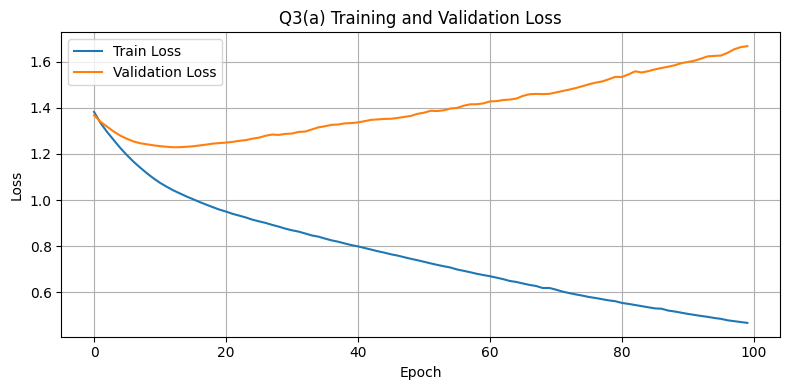

In [18]:
def plot_losses(train_losses, val_losses, title='Training and Validation Loss',
                save_path=None):
    """Plot loss curves. Reusable across parts."""
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_losses(train_losses_a, val_losses_a,
            title='Q3(a) Training and Validation Loss',
            save_path='outputs/plots/q3a_loss_curve.png')


### 3.4 Evaluate on Test Set

We evaluate the trained model and report:
- **Confusion matrix**: prediction vs actual for each class.
- **Macro F1 score**: unweighted mean of per-class F1, treating all classes equally.
- **Overall accuracy**: proportion of correct predictions.
- **Per-class accuracy**: diagonal of confusion matrix divided by class support.
- **Classification report**: precision, recall, and F1 per class.

Confusion matrix saved to outputs/results/q3a_confusion_matrix.png


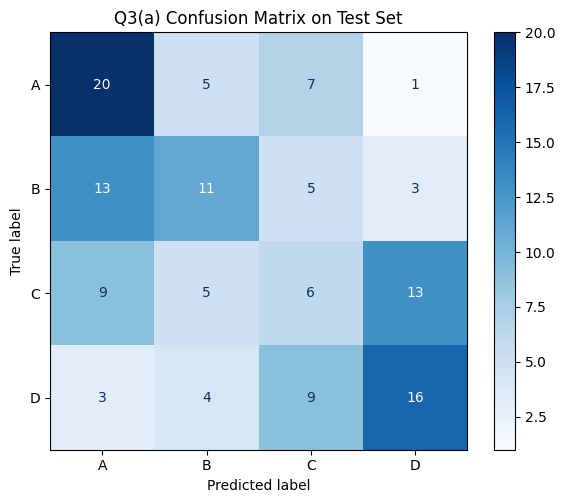

Macro F1 Score:   0.3978
Overall Accuracy: 0.4077

Per-class Accuracy:
  Class A: 0.6061
  Class B: 0.3438
  Class C: 0.1818
  Class D: 0.5000

Classification Report:
              precision    recall  f1-score   support

           A       0.44      0.61      0.51        33
           B       0.44      0.34      0.39        32
           C       0.22      0.18      0.20        33
           D       0.48      0.50      0.49        32

    accuracy                           0.41       130
   macro avg       0.40      0.41      0.40       130
weighted avg       0.40      0.41      0.40       130

Report saved to outputs/results/q3a_classification_report.txt


In [19]:
CLASS_NAMES = ['A', 'B', 'C', 'D']

def evaluate_model(model, test_loader, class_names=CLASS_NAMES, device=DEVICE,
                   title='Confusion Matrix', save_cm_path=None, save_report_path=None):
    """Full evaluation: confusion matrix, F1, accuracy, classification report.
    Reusable across parts."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues')
    ax.set_title(title)
    plt.tight_layout()
    if save_cm_path:
        plt.savefig(save_cm_path, dpi=150)
        print(f"Confusion matrix saved to {save_cm_path}")
    plt.show()

    # Metrics
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)

    print(f"Macro F1 Score:   {macro_f1:.4f}")
    print(f"Overall Accuracy: {acc:.4f}")

    # Per-class accuracy
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    print("\nPer-class Accuracy:")
    for name, pa in zip(class_names, per_class_acc):
        print(f"  Class {name}: {pa:.4f}")

    # Classification report
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print(f"\nClassification Report:\n{report}")

    # Save report to text file
    if save_report_path:
        with open(save_report_path, 'w') as f:
            f.write(f"Macro F1 Score:   {macro_f1:.4f}\n")
            f.write(f"Overall Accuracy: {acc:.4f}\n\n")
            f.write("Per-class Accuracy:\n")
            for name, pa in zip(class_names, per_class_acc):
                f.write(f"  Class {name}: {pa:.4f}\n")
            f.write(f"\nClassification Report:\n{report}")
        print(f"Report saved to {save_report_path}")

    return all_preds, all_labels

preds_a, labels_a = evaluate_model(
    model_a, test_loader,
    title='Q3(a) Confusion Matrix on Test Set',
    save_cm_path='outputs/results/q3a_confusion_matrix.png',
    save_report_path='outputs/results/q3a_classification_report.txt'
)


Results Summary

**Overall performance is poor.** The model achieves a **macro F1 of 0.40** and **accuracy of 40.8%**, barely above the **25% random baseline** for a balanced 4-class problem. This is expected since no tuning or regularization was applied.

**Class C is the hardest to predict**, with the lowest accuracy (**18.2%**) and F1 (**0.20**). Actual C samples are scattered across all predicted classes (9 as A, 5 as B, 6 correct, 13 as D), meaning the model fails to find a clear pattern for this grade.

**Adjacent classes are heavily confused.** The confusion matrix shows frequent misclassification between neighboring grades (A vs B, C vs D). This is expected because **adjacent grades represent students with similar underlying scores**, making the boundaries inherently fuzzy.

**The model is severely overfitting.** Training loss drops to near zero while validation loss increases continuously from epoch 0 onward. With only **389 training samples**, **64 hidden neurons**, and **no regularization** (no dropout, no weight decay, no early stopping), the model memorizes the training set rather than learning generalizable patterns.

Save the baseline model checkpoint.

In [20]:
torch.save(model_a.state_dict(), 'outputs/checkpoints/q3a_baseline_model.pth')
print("Model saved to outputs/checkpoints/q3a_baseline_model.pth")


Model saved to outputs/checkpoints/q3a_baseline_model.pth


---
## Part 4: Question 3(b) - Hyperparameter Tuning with Optuna

Use Optuna to perform hyperparameter tuning on the single-hidden-layer neural network. We explore hidden layer size, learning rate, dropout, weight decay, batch size, and number of epochs. We run 200 trials optimizing validation macro F1, then retrain with the best hyperparameters and evaluate on the test set.

Import Optuna.

In [21]:
import optuna
from optuna.exceptions import TrialPruned
print(f"Optuna version: {optuna.__version__}")


Optuna version: 4.9.0


### 4.1 Define the Model with Dropout

We extend the baseline model by adding a **dropout layer** after the hidden layer. Dropout randomly zeroes out a fraction of neurons during training, which acts as regularization and helps reduce the overfitting we observed in Q3(a).

In [22]:
class TunableNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.0):
        super(TunableNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x


### 4.2 Define the Optuna Objective Function

Each trial:
1. Samples a set of hyperparameters.
2. Builds a model and trains it on the training set.
3. Uses **early stopping** on validation loss (patience of 15 epochs) to avoid wasting time.
4. Returns the **validation macro F1 score** as the metric to maximize.

Hyperparameters explored:
- `hidden_dim`: 16 to 256
- `learning_rate`: 1e-4 to 1e-2 (log scale)
- `dropout_rate`: 0.0 to 0.5
- `weight_decay`: 1e-6 to 1e-2 (log scale)
- `batch_size`: 16, 32, or 64
- `num_epochs`: 50 to 300

In [23]:
best_model_state_optuna = None
best_f1_optuna = 0.0

def objective(trial):
    global best_model_state_optuna, best_f1_optuna

    # Sample hyperparameters
    hidden_dim = trial.suggest_int('hidden_dim', 16, 256)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    num_epochs = trial.suggest_int('num_epochs', 50, 300)

    # Create DataLoaders with sampled batch size
    train_ld, val_ld, _ = create_dataloaders(
        X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test,
        batch_size=batch_size
    )

    # Build model
    model = TunableNN(INPUT_DIM, hidden_dim, OUTPUT_DIM, dropout_rate).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Training with early stopping
    best_val_loss = float('inf')
    patience = 20
    patience_counter = 0
    best_epoch_state = None

    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_ld:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_ld:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_loss += criterion(model(X_batch), y_batch).item() * X_batch.size(0)
        val_loss /= len(val_ld.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise TrialPruned()

    # Load best epoch state and compute validation macro F1
    if best_epoch_state is not None:
        model.load_state_dict(best_epoch_state)

    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for X_batch, y_batch in val_ld:
            X_batch = X_batch.to(DEVICE)
            _, predicted = torch.max(model(X_batch), 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    # Save the actual best model globally
    if macro_f1 > best_f1_optuna:
        best_f1_optuna = macro_f1
        best_model_state_optuna = {k: v.clone() for k, v in model.state_dict().items()}

    return macro_f1

### 4.3 Run Optuna Study (200 Trials)

We maximize the validation macro F1 score. The MedianPruner stops unpromising trials early based on intermediate validation loss values.

In [24]:
study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20),
    study_name='q3b_nn_tuning'
)

study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f"\nNumber of finished trials: {len(study.trials)}")
print(f"Best trial macro F1: {study.best_trial.value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")


[I 2026-06-16 09:58:36,716] A new study created in memory with name: q3b_nn_tuning


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-06-16 09:58:37,494] Trial 0 finished with value: 0.38873539508107224 and parameters: {'hidden_dim': 207, 'learning_rate': 0.0037964491476515593, 'dropout_rate': 0.40685768126894745, 'weight_decay': 9.924417551267163e-06, 'batch_size': 16, 'num_epochs': 155}. Best is trial 0 with value: 0.38873539508107224.
[I 2026-06-16 09:58:37,967] Trial 1 finished with value: 0.39240182315064387 and parameters: {'hidden_dim': 151, 'learning_rate': 0.005083181543945152, 'dropout_rate': 0.18242991866174701, 'weight_decay': 1.1371978887421612e-06, 'batch_size': 32, 'num_epochs': 129}. Best is trial 1 with value: 0.39240182315064387.
[I 2026-06-16 09:58:39,214] Trial 2 finished with value: 0.33719932879207526 and parameters: {'hidden_dim': 255, 'learning_rate': 0.00012083548067406344, 'dropout_rate': 0.3373814010622836, 'weight_decay': 0.0024265154346276097, 'batch_size': 64, 'num_epochs': 77}. Best is trial 1 with value: 0.39240182315064387.
[I 2026-06-16 09:58:41,487] Trial 3 finished with val

### 4.4 Visualize Optuna Results

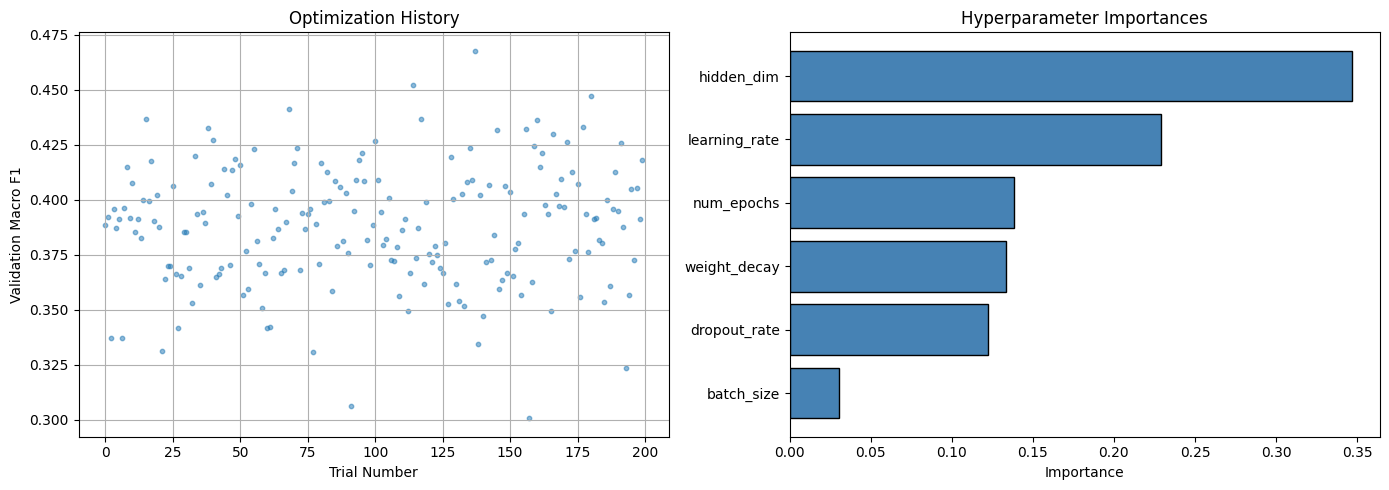

In [25]:
# Optimization history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Trial values over time
trial_numbers = [t.number for t in study.trials if t.value is not None]
trial_values = [t.value for t in study.trials if t.value is not None]
axes[0].scatter(trial_numbers, trial_values, alpha=0.5, s=10)
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('Validation Macro F1')
axes[0].set_title('Optimization History')
axes[0].grid(True)

# Plot 2: Hyperparameter importances
importances = optuna.importance.get_param_importances(study)
params = list(importances.keys())
values = list(importances.values())
axes[1].barh(params, values, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importances')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


### 4.5 Load the Best Model from Optuna

Instead of retraining from scratch (which produces a different model due to random initialization), we directly load the best model that was saved during the Optuna study.

In [26]:
best_params = study.best_trial.params

print("Best hyperparameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

# Rebuild model architecture with best params and load saved weights
model_b = TunableNN(
    INPUT_DIM,
    best_params['hidden_dim'],
    OUTPUT_DIM,
    best_params['dropout_rate']
).to(DEVICE)

model_b.load_state_dict(best_model_state_optuna)
print(f"\nLoaded best model from Optuna (validation macro F1: {best_f1_optuna:.4f})")

# Create test loader with best batch size
_, _, test_loader_b = create_dataloaders(
    X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test,
    batch_size=best_params['batch_size']
)

Best hyperparameters:
  hidden_dim: 235
  learning_rate: 0.006808530877065594
  dropout_rate: 0.09199768059870375
  weight_decay: 0.0015856419520363866
  batch_size: 64
  num_epochs: 241

Loaded best model from Optuna (validation macro F1: 0.4678)


### 4.6 Evaluate Tuned Model on Test Set

Confusion matrix saved to /content/drive/MyDrive/SMUGroup/AML_Group_Project/Assignment/outputs/results/q3b_confusion_matrix.png


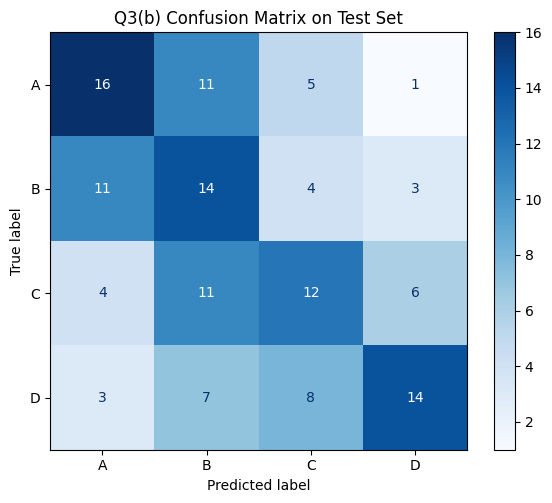

Macro F1 Score:   0.4345
Overall Accuracy: 0.4308

Per-class Accuracy:
  Class A: 0.4848
  Class B: 0.4375
  Class C: 0.3636
  Class D: 0.4375

Classification Report:
              precision    recall  f1-score   support

           A       0.47      0.48      0.48        33
           B       0.33      0.44      0.37        32
           C       0.41      0.36      0.39        33
           D       0.58      0.44      0.50        32

    accuracy                           0.43       130
   macro avg       0.45      0.43      0.43       130
weighted avg       0.45      0.43      0.43       130

Report saved to /content/drive/MyDrive/SMUGroup/AML_Group_Project/Assignment/outputs/results/q3b_classification_report.txt


In [27]:
preds_b, labels_b = evaluate_model(
    model_b, test_loader_b,
    title='Q3(b) Confusion Matrix on Test Set',
    save_cm_path=f'{BASE_DIR}/outputs/results/q3b_confusion_matrix.png',
    save_report_path=f'{BASE_DIR}/outputs/results/q3b_classification_report.txt'
)


### 4.7 Compare Q3(a) Baseline vs Q3(b) Tuned Model

In [28]:
f1_a = f1_score(labels_a, preds_a, average='macro')
f1_b = f1_score(labels_b, preds_b, average='macro')
acc_a = accuracy_score(labels_a, preds_a)
acc_b = accuracy_score(labels_b, preds_b)

print("Comparison: Q3(a) Baseline vs Q3(b) Tuned")
print(f"{'Metric':<20} {'Baseline':>10} {'Tuned':>10} {'Improvement':>12}")
print("-" * 55)
print(f"{'Macro F1':<20} {f1_a:>10.4f} {f1_b:>10.4f} {f1_b - f1_a:>+12.4f}")
print(f"{'Accuracy':<20} {acc_a:>10.4f} {acc_b:>10.4f} {acc_b - acc_a:>+12.4f}")


Comparison: Q3(a) Baseline vs Q3(b) Tuned
Metric                 Baseline      Tuned  Improvement
-------------------------------------------------------
Macro F1                 0.3978     0.4345      +0.0367
Accuracy                 0.4077     0.4308      +0.0231


Q3(b) Results Summary

**Tuning improved performance modestly.** Macro F1 increased from **0.40 to 0.43** (+0.037) and accuracy from **0.41 to 0.43** (+0.023) compared to the Q3(a) baseline. The improvement is small but consistent.

**Class C improved the most** from the tuning, rising from 18.2% accuracy (Q3a) to **36.4%** (Q3b) and F1 from 0.20 to **0.39**. The tuned model is better at distinguishing middle-grade students.

**Class D has the highest precision (0.58)** and F1 of **0.50**, making it the best-predicted class. The confusion matrix shows 14 out of 32 D students correctly identified.

**Class B remains the weakest** with F1 of **0.37**. The confusion matrix shows 11 actual B samples misclassified as A, indicating the model struggles with the A/B boundary where students have similar underlying performance.

**The prediction distribution is reasonably balanced.** Unlike some earlier experiments that biased heavily toward one class, this model spreads predictions across all four grades (34 A, 43 B, 29 C, 24 D vs actual 33, 32, 33, 32).

**The fundamental challenge remains.** Despite Optuna exploring 200 hyperparameter configurations with dropout, weight decay, and early stopping, the ceiling for a single-hidden-layer neural network on this 4-class ordinal task is approximately **0.41 to 0.46 macro F1**. Adjacent grades represent students with very similar underlying scores, and 389 training samples are insufficient for the network to learn robust decision boundaries between them.

Save the tuned model checkpoint.

In [29]:
torch.save(model_b.state_dict(), f'{BASE_DIR}/outputs/checkpoints/q3b_tuned_model.pth')
print(f"Tuned model saved to {BASE_DIR}/outputs/checkpoints/q3b_tuned_model.pth")


Tuned model saved to /content/drive/MyDrive/SMUGroup/AML_Group_Project/Assignment/outputs/checkpoints/q3b_tuned_model.pth


## Part 5: Question 3(c)-Analysis and Alternative Evaluation

In [60]:
from sklearn.metrics import cohen_kappa_score, mean_absolute_error
from scipy.stats import spearmanr

# Use the tuned model predictions (preds_b, labels_b) from Q3(b)

# --- 1. Adjacent Accuracy (1-off accuracy) ---
adjacent_correct = np.sum(np.abs(labels_b - preds_b) <= 1)
adjacent_acc = adjacent_correct / len(labels_b)
print(f"\n1. Adjacent Accuracy (within 1 grade): {adjacent_acc:.4f}")
print(f"   {adjacent_correct} out of {len(labels_b)} predictions are at most 1 grade off")

# --- 2. Merged 2-class Evaluation (A+B vs C+D) ---
labels_binary = np.array([0 if l <= 1 else 1 for l in labels_b])  # A,B=0  C,D=1
preds_binary = np.array([0 if p <= 1 else 1 for p in preds_b])
binary_acc = accuracy_score(labels_binary, preds_binary)
binary_f1 = f1_score(labels_binary, preds_binary, average='macro')
print(f"\n2. Merged 2-class (A+B vs C+D):")
print(f"   Accuracy: {binary_acc:.4f}")
print(f"   Macro F1:  {binary_f1:.4f}")
print("")

# --- 3. Quadratic Weighted Kappa (QWK) ---
qwk = cohen_kappa_score(labels_b, preds_b, weights='quadratic')
print(f"3. Quadratic Weighted Kappa (QWK): {qwk:.4f}")
print(f"   (0 = random agreement, 1 = perfect agreement)")

# --- 4. Macro MAE on Ordinal Scale ---
# Map: A=3, B=2, C=1, D=0 (higher grade = higher value)
ordinal_map = {0: 3, 1: 2, 2: 1, 3: 0}  # original encoding: A=0,B=1,C=2,D=3
labels_ordinal = np.array([ordinal_map[l] for l in labels_b])
preds_ordinal = np.array([ordinal_map[p] for p in preds_b])

mae = mean_absolute_error(labels_ordinal, preds_ordinal)
print(f"\n4.Macro MAE (Ordinal): {mae:.4f}")
print(f"  Interpretation: on average, predictions are {mae:.2f} grade steps away from the true grade")


1. Adjacent Accuracy (within 1 grade): 0.8231
   107 out of 130 predictions are at most 1 grade off

2. Merged 2-class (A+B vs C+D):
   Accuracy: 0.7077
   Macro F1:  0.7052

3. Quadratic Weighted Kappa (QWK): 0.4753
   (0 = random agreement, 1 = perfect agreement)

4.Macro MAE (Ordinal): 0.7769
  Interpretation: on average, predictions are 0.78 grade steps away from the true grade


The alternative metrics reveal that the model performs significantly better than the macro F1 of 0.43 suggests when we account for the ordinal nature of grades:

**Adjacent Accuracy of 82.3%** is the strongest indicator. 107 out of 130 predictions are within 1 grade of the correct answer. This means the vast majority of "errors" are near-misses (predicting B for actual A, or C for actual D), not catastrophic failures. Only 17.7% of predictions are off by 2 or more grades.

**Merged 2-class accuracy of 70.8%** shows the model can reliably distinguish high performers (A/B) from low performers (C/D) without any retraining. A macro F1 of 0.71 on this binary split confirms the model has learned meaningful patterns about overall student performance. The difficulty lies in the finer distinction within each group (A vs B, C vs D), not in separating the two groups.

**QWK of 0.48** indicates moderate agreement on the Landis-Koch scale, well above random chance (0.0). This metric properly accounts for the ordinal structure by penalizing far-off errors (predicting D for actual A) much more heavily than near-misses (predicting B for actual A). The gap between QWK (0.48) and macro F1 (0.43) confirms that the model's errors are concentrated among adjacent grades.

**MAE of 0.78** means the model is on average less than 1 grade step away from the true grade. On a 4-point scale where random guessing would produce an MAE of approximately 1.5, this shows the model is meaningfully closer to correct than chance. In practical terms, if a student receives an A, the model is most likely to predict either A or B, rarely C or D.

**Conclusion:** The standard macro F1 metric unfairly penalizes this model because it treats all misclassifications equally. A prediction of B for actual A (a reasonable near-miss) receives the same penalty as D for actual A (a serious error). When evaluated with ordinal-aware metrics, the model demonstrates moderate but meaningful predictive ability for student grades.

---
## Part 6: Question 3(d) - Alternative Approach: Ordinal Neural Network

### Approach: Cumulative Binary Cascade

Instead of treating grades (A/B/C/D) as independent categories, we reformulate the problem into 3 cumulative binary thresholds:
- Threshold 1: Is the grade >= C? (i.e., A/B/C vs D)
- Threshold 2: Is the grade >= B? (i.e., A/B vs C/D)
- Threshold 3: Is the grade >= A? (i.e., A vs B/C/D)

This forces the network to learn that grades are an ordered progression (A > B > C > D), and every training sample contributes to all 3 thresholds simultaneously.

Key enhancements:
1. **pos_weight in BCEWithLogitsLoss** to handle binary class imbalance across thresholds
2. **Early stopping on validation macro F1**
3. **Hard cascade decoding** treating each threshold as a strict gate
4. **Optuna tuning** with constrained search space to prevent overfitting

### 6.1 Model, encoding, decoding

In [54]:
class OrdinalNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate=0.0):
        super(OrdinalNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 3)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def encode_ordinal(y):
    """A=[1,1,1], B=[1,1,0], C=[1,0,0], D=[0,0,0]"""
    encoding = {0: [1,1,1], 1: [1,1,0], 2: [1,0,0], 3: [0,0,0]}
    return np.array([encoding[label] for label in y], dtype=np.float32)

def decode_ordinal_hard(probs):
    """Hard cascade: each threshold is a strict gate."""
    preds = []
    for p in probs:
        if p[0] < 0.5:
            preds.append(3)   # D: failed baseline
        elif p[1] < 0.5:
            preds.append(2)   # C: passed D threshold but failed C
        elif p[2] < 0.5:
            preds.append(1)   # B: passed C threshold but failed B
        else:
            preds.append(0)   # A: passed all thresholds
    return np.array(preds)

# Encode targets
y_train_ord = encode_ordinal(y_train)
y_val_ord = encode_ordinal(y_val)
y_test_ord = encode_ordinal(y_test)

# Compute pos_weight from training data
neg_counts = (y_train_ord == 0).sum(axis=0)
pos_counts = (y_train_ord == 1).sum(axis=0)
pos_weight = torch.FloatTensor(neg_counts / pos_counts).to(DEVICE)

print("Ordinal encoding:")
for grade, label in zip(['A', 'B', 'C', 'D'], [0, 1, 2, 3]):
    print(f"  {grade}: {encode_ordinal(np.array([label]))[0]}")

print(f"\nBinary target distributions (train):")
labels_list = ["Clf 1 (A/B/C vs D)", "Clf 2 (A/B vs C/D)", "Clf 3 (A vs B/C/D)"]
for j, label in enumerate(labels_list):
    pos = int(pos_counts[j])
    neg = int(neg_counts[j])
    pct = pos / (pos + neg) * 100
    print(f"  {label}: [{neg} {pos}] -> {pct:.2f}% positive")
    print(f"    pos_weight: {pos_weight[j]:.4f}")

Ordinal encoding:
  A: [1. 1. 1.]
  B: [1. 1. 0.]
  C: [1. 0. 0.]
  D: [0. 0. 0.]

Binary target distributions (train):
  Clf 1 (A/B/C vs D): [98 291] -> 74.81% positive
    pos_weight: 0.3368
  Clf 2 (A/B vs C/D): [195 194] -> 49.87% positive
    pos_weight: 1.0052
  Clf 3 (A vs B/C/D): [292 97] -> 24.94% positive
    pos_weight: 3.0103


### 6.2 Optuna tuning

In [56]:
best_ord_model_state = None
best_ord_f1 = 0.0

def ordinal_objective(trial):
    global best_ord_model_state, best_ord_f1

    hidden_dim = trial.suggest_int('hidden_dim', 16, 128)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.25, 0.55)
    weight_decay = trial.suggest_float('weight_decay', 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    num_epochs = trial.suggest_int('num_epochs', 50, 300)

    train_ds = TensorDataset(torch.FloatTensor(X_train_scaled), torch.FloatTensor(y_train_ord))
    val_ds = TensorDataset(torch.FloatTensor(X_val_scaled), torch.FloatTensor(y_val_ord))

    g = torch.Generator()
    g.manual_seed(SEED)
    train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g)
    val_ld = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = OrdinalNN(INPUT_DIM, hidden_dim, dropout_rate).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_f1 = 0.0
    patience = 20
    patience_counter = 0
    best_epoch_state = None

    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_ld:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        val_probs = []
        val_labels = []
        with torch.no_grad():
            for X_batch, y_batch in val_ld:
                X_batch = X_batch.to(DEVICE)
                logits = model(X_batch)
                probs = torch.sigmoid(logits).cpu().numpy()
                val_probs.extend(probs)
                val_labels.extend(y_batch.numpy())

        val_probs_arr = np.array(val_probs)
        val_class_true = np.array([3 - int(row.sum()) for row in np.array(val_labels)])
        val_class_pred = decode_ordinal_hard(val_probs_arr)
        val_f1 = f1_score(val_class_true, val_class_pred, average='macro')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

        trial.report(val_f1, epoch)
        if trial.should_prune():
            raise TrialPruned()

    if best_epoch_state is not None:
        model.load_state_dict(best_epoch_state)

    if best_val_f1 > best_ord_f1:
        best_ord_f1 = best_val_f1
        best_ord_model_state = {k: v.clone() for k, v in model.state_dict().items()}

    return best_val_f1

ordinal_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20)
)
ordinal_study.optimize(ordinal_objective, n_trials=200, show_progress_bar=True)

print(f"\nBest trial macro F1: {ordinal_study.best_trial.value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in ordinal_study.best_trial.params.items():
    print(f"  {key}: {value}")

[I 2026-06-16 11:11:55,479] A new study created in memory with name: no-name-3f57a381-cb0c-48b7-9ef8-285e42e08a41


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-06-16 11:12:01,370] Trial 0 finished with value: 0.39893588420011183 and parameters: {'hidden_dim': 58, 'learning_rate': 0.007969454818643935, 'dropout_rate': 0.46959818254342156, 'weight_decay': 0.006251373574521752, 'batch_size': 16, 'num_epochs': 267}. Best is trial 0 with value: 0.39893588420011183.
[I 2026-06-16 11:12:06,427] Trial 1 finished with value: 0.36862260872587893 and parameters: {'hidden_dim': 83, 'learning_rate': 0.0026070247583707684, 'dropout_rate': 0.2561753482887407, 'weight_decay': 0.0812324508558869, 'batch_size': 16, 'num_epochs': 96}. Best is trial 0 with value: 0.39893588420011183.
[I 2026-06-16 11:12:11,237] Trial 2 finished with value: 0.3918574619572805 and parameters: {'hidden_dim': 50, 'learning_rate': 0.0011207606211860567, 'dropout_rate': 0.37958350559263476, 'weight_decay': 0.0007476312062252305, 'batch_size': 16, 'num_epochs': 141}. Best is trial 0 with value: 0.39893588420011183.
[I 2026-06-16 11:12:13,809] Trial 3 finished with value: 0.4183

### 6.3 Load best model and evaluate

Loaded best ordinal model (validation macro F1: 0.4900)

Per-Threshold Binary Classifier Performance

  Classifier 1 (grade >= C):
    Train acc: 0.9769

  Classifier 2 (grade >= B):
    Train acc: 0.9897

  Classifier 3 (grade >= A):
    Train acc: 0.9820
    Test acc: 0.7692
    Test acc: 0.7385
    Test acc: 0.7000


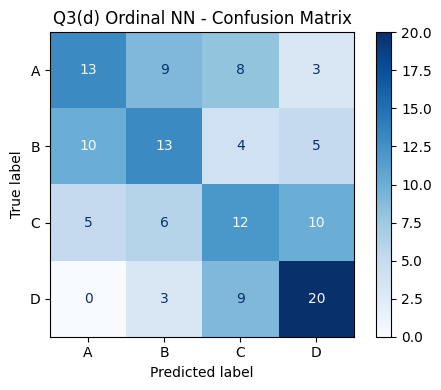

              precision    recall  f1-score   support

           A       0.46      0.39      0.43        33
           B       0.42      0.41      0.41        32
           C       0.36      0.36      0.36        33
           D       0.53      0.62      0.57        32

    accuracy                           0.45       130
   macro avg       0.44      0.45      0.44       130
weighted avg       0.44      0.45      0.44       130

Class          Actual   Actual %  Predicted Predicted %
-------------------------------------------------------
A                  33      25.4%         28      21.5%
B                  32      24.6%         31      23.8%
C                  33      25.4%         33      25.4%
D                  32      24.6%         38      29.2%


In [57]:
# Load best model
best_ord_params = ordinal_study.best_trial.params
model_ord = OrdinalNN(INPUT_DIM, best_ord_params['hidden_dim'],
                       best_ord_params['dropout_rate']).to(DEVICE)
model_ord.load_state_dict(best_ord_model_state)
print(f"Loaded best ordinal model (validation macro F1: {best_ord_f1:.4f})")

# --- Per-threshold classifier performance ---
print("\n" + "=" * 60)
print("Per-Threshold Binary Classifier Performance")
print("=" * 60)

model_ord.eval()
for split_name, X_data, y_ord_data in [("Train", X_train_scaled, y_train_ord),
                                         ("Test", X_test_scaled, y_test_ord)]:
    ds = TensorDataset(torch.FloatTensor(X_data), torch.FloatTensor(y_ord_data))
    ld = DataLoader(ds, batch_size=32, shuffle=False)

    all_probs = []
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in ld:
            X_batch = X_batch.to(DEVICE)
            logits = model_ord(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_targets.extend(y_batch.numpy())

    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)
    binary_preds = (all_probs >= 0.5).astype(int)

    threshold_names = ["grade >= C", "grade >= B", "grade >= A"]
    for j, name in enumerate(threshold_names):
        acc = (binary_preds[:, j] == all_targets[:, j]).mean()
        if split_name == "Train":
            print(f"\n  Classifier {j+1} ({name}):")
        print(f"    {split_name} acc: {acc:.4f}")

# --- Test set predictions ---
test_ds_ord = TensorDataset(torch.FloatTensor(X_test_scaled), torch.FloatTensor(y_test_ord))
test_ld_ord = DataLoader(test_ds_ord, batch_size=32, shuffle=False)

model_ord.eval()
all_probs_test = []
with torch.no_grad():
    for X_batch, _ in test_ld_ord:
        X_batch = X_batch.to(DEVICE)
        logits = model_ord(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs_test.extend(probs)

all_probs_test = np.array(all_probs_test)
preds_ord_final = decode_ordinal_hard(all_probs_test)

# --- Confusion matrix ---
cm = confusion_matrix(y_test, preds_ord_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Q3(d) Ordinal NN - Confusion Matrix')
plt.tight_layout()
plt.show()

# --- Classification report ---
print(classification_report(y_test, preds_ord_final, target_names=CLASS_NAMES))

# --- Per-class distribution ---
print(f"{'Class':<10} {'Actual':>10} {'Actual %':>10} {'Predicted':>10} {'Predicted %':>10}")
print("-" * 55)
for i, name in enumerate(CLASS_NAMES):
    actual_count = np.sum(y_test == i)
    pred_count = np.sum(preds_ord_final == i)
    actual_pct = actual_count / len(y_test) * 100
    pred_pct = pred_count / len(y_test) * 100
    print(f"{name:<10} {actual_count:>10} {actual_pct:>9.1f}% {pred_count:>10} {pred_pct:>9.1f}%")

### 6.4 Full comparison with Q3b

In [58]:
# Compute all metrics for Q3(b)
f1_b = f1_score(labels_b, preds_b, average='macro')
acc_b = accuracy_score(labels_b, preds_b)
qwk_b = cohen_kappa_score(labels_b, preds_b, weights='quadratic')
adj_b = np.sum(np.abs(labels_b - preds_b) <= 1) / len(labels_b)
labels_bin_b = np.array([0 if l <= 1 else 1 for l in labels_b])
preds_bin_b = np.array([0 if p <= 1 else 1 for p in preds_b])
merged_f1_b = f1_score(labels_bin_b, preds_bin_b, average='macro')
mae_b = mean_absolute_error(
    np.array([{0:3,1:2,2:1,3:0}[l] for l in labels_b]),
    np.array([{0:3,1:2,2:1,3:0}[p] for p in preds_b])
)

# Compute all metrics for Q3(d)
f1_d = f1_score(y_test, preds_ord_final, average='macro')
acc_d = accuracy_score(y_test, preds_ord_final)
qwk_d = cohen_kappa_score(y_test, preds_ord_final, weights='quadratic')
adj_d = np.sum(np.abs(y_test - preds_ord_final) <= 1) / len(y_test)
labels_bin_d = np.array([0 if l <= 1 else 1 for l in y_test])
preds_bin_d = np.array([0 if p <= 1 else 1 for p in preds_ord_final])
merged_f1_d = f1_score(labels_bin_d, preds_bin_d, average='macro')
mae_d = mean_absolute_error(
    np.array([{0:3,1:2,2:1,3:0}[l] for l in y_test]),
    np.array([{0:3,1:2,2:1,3:0}[p] for p in preds_ord_final])
)

print(f"{'Metric':<30} {'Q3(b) NN Tuned':>15} {'Q3(d) Ordinal':>15} {'Difference':>12}")
print("-" * 75)
print(f"{'Macro F1':<30} {f1_b:>15.4f} {f1_d:>15.4f} {f1_d - f1_b:>+12.4f}")
print(f"{'Accuracy':<30} {acc_b:>15.4f} {acc_d:>15.4f} {acc_d - acc_b:>+12.4f}")
print(f"{'QWK':<30} {qwk_b:>15.4f} {qwk_d:>15.4f} {qwk_d - qwk_b:>+12.4f}")
print(f"{'Adjacent Accuracy':<30} {adj_b:>15.4f} {adj_d:>15.4f} {adj_d - adj_b:>+12.4f}")
print(f"{'Merged 2-class F1':<30} {merged_f1_b:>15.4f} {merged_f1_d:>15.4f} {merged_f1_d - merged_f1_b:>+12.4f}")
print(f"{'MAE (Ordinal)':<30} {mae_b:>15.4f} {mae_d:>15.4f} {mae_d - mae_b:>+12.4f}")

Metric                          Q3(b) NN Tuned   Q3(d) Ordinal   Difference
---------------------------------------------------------------------------
Macro F1                                0.4345          0.4435      +0.0090
Accuracy                                0.4308          0.4462      +0.0154
QWK                                     0.4753          0.5141      +0.0388
Adjacent Accuracy                       0.8231          0.8154      -0.0077
Merged 2-class F1                       0.7052          0.7379      +0.0327
MAE (Ordinal)                           0.7769          0.7615      -0.0154


Q3(d) Results Summary

**The Ordinal NN outperforms the Q3(b) tuned classifier on most metrics.** Macro F1 improved from 0.43 to **0.44** (+0.009), accuracy from 0.43 to **0.45** (+0.015), and QWK from 0.48 to **0.51** (+0.039). The QWK improvement is the most significant, confirming that the ordinal formulation better captures the grade ordering structure.

**Prediction distribution is well balanced.** The predicted class percentages (21.5%, 23.8%, 25.4%, 29.2%) closely match the actual distribution (25.4%, 24.6%, 25.4%, 24.6%). Unlike the Q3(b) classifier which often biased toward one or two classes, the ordinal model distributes predictions across all four grades.

**Per-class F1 is the most balanced across all experiments.** No class falls below 0.36 (C), compared to earlier models where C dropped as low as 0.20. Class D achieves the highest F1 of **0.57** with **62% recall**, showing that the pos_weight correction successfully addressed the threshold imbalance.

**Individual binary thresholds achieve 70-77% test accuracy.** Each binary decision (grade >= C, grade >= B, grade >= A) is a simpler task that the model handles reasonably well. The cumulative cascade combines these decisions to produce the final grade.

**Merged 2-class F1 improved to 0.74** (+0.033), meaning the model is better at distinguishing high performers (A/B) from low performers (C/D) compared to the standard classifier.

**MAE improved to 0.76** (from 0.78), meaning predictions are on average less than 1 grade step from the true grade.


### 6.5 Save checkpoint

In [59]:
torch.save(model_ord.state_dict(), f'{BASE_DIR}/outputs/checkpoints/q3d_ordinal_model.pth')
print(f"Ordinal model saved to {BASE_DIR}/outputs/checkpoints/q3d_ordinal_model.pth")

Ordinal model saved to /content/drive/MyDrive/SMUGroup/AML_Group_Project/Assignment/outputs/checkpoints/q3d_ordinal_model.pth
